In [2]:
import json
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
from collections import OrderedDict
from collections import Counter, defaultdict, OrderedDict

import statsmodels.api as sm
from scipy.stats import norm
from scipy.interpolate import interp1d

%config InlineBackend.figure_format='retina'

In [3]:
n_folders = len([f for f in os.listdir("/Users/laura/Documents/TBC/evals/manuscripts") if os.path.isdir(os.path.join("/Users/laura/Documents/TBC/evals/manuscripts", f))])
print(n_folders)

18576


In [4]:
# -- Load post2023 manuscripts list --
post2023_manuscripts = set()
with open("/Users/laura/Documents/TBC/evals/post2023_manuscripts.txt") as f:
    for line in f:
        parts = line.strip().split(",")
        if len(parts) > 1:
            manuscript_id = parts[1].strip()
            if manuscript_id:
                post2023_manuscripts.add(manuscript_id)

base_path = "manuscripts"
dfs_claims = []

for manuscript_id in os.listdir(base_path):
    manuscript_path = os.path.join(base_path, manuscript_id)
    if not os.path.isdir(manuscript_path) or manuscript_id.startswith('.'):
        continue
    version_dirs = [
        d for d in os.listdir(manuscript_path)
        if os.path.isdir(os.path.join(manuscript_path, d)) and not d.startswith('.')
    ]
    use_version = None

    if manuscript_id in post2023_manuscripts:
        # For post2023, use v1 only if available
        if "v1" in version_dirs:
            use_version = "v1"
    else:
        # For others, use highest version number available (e.g., v3 > v2 > v1)
        # Assume version dirs are named 'v1', 'v2', ... 'vn'
        numeric_versions = []
        for v in version_dirs:
            if v.startswith('v'):
                try:
                    num = int(v[1:])
                    numeric_versions.append((num, v))
                except Exception:
                    pass
        if numeric_versions:
            # Get the highest version
            max_version = max(numeric_versions)[1]
            use_version = max_version

    if use_version:
        v_path = os.path.join(manuscript_path, use_version)
        claims_json_path = os.path.join(v_path, "claims.json")
        if os.path.exists(claims_json_path):
            with open(claims_json_path, "r") as f:
                claims = json.load(f)
            df_claims_part = pd.DataFrame(claims)
            df_claims_part["manuscript_id"] = manuscript_id
            df_claims_part["version"] = use_version
            dfs_claims.append(df_claims_part)

# Concatenate claims dataframes
df_claims = pd.concat(dfs_claims, ignore_index=True)

In [5]:
df_claims

,claim_id,claim,claim_type,source,source_type,evidence,evidence_type,manuscript_id,version
0,C1,A duration code instructs stimulus-specific cr...,EXPLICIT,Our systems-level analyses identified a durati...,[TEXT],Supported by computational modeling and experi...,"[DATA, INFERENCE]",elife-05648,v2
1,C2,LTβR costimulation synergistically enhanced th...,EXPLICIT,"Indeed, LTβR costimulation synergistically enh...",[TEXT],Demonstrated by EMSA showing augmented late Re...,[DATA],elife-05648,v2
2,C3,Concomitant LTβR signal targeted TLR4-induced ...,EXPLICIT,Concomitant LTβR signal targeted TLR4-induced ...,[TEXT],Supported by immunoblot data showing p52 gener...,[DATA],elife-05648,v2
3,C4,p100 processing into p52 neutralized p100 medi...,EXPLICIT,Concomitant LTβR signal targeted TLR4-induced ...,[TEXT],Supported by immunoprecipitation data showing ...,"[DATA, INFERENCE]",elife-05648,v2
4,C5,p100 processing into p52 potently generated Re...,EXPLICIT,Concomitant LTβR signal targeted TLR4-induced ...,[TEXT],Supported by EMSA showing RelA:p52 dimer as a ...,"[DATA, INFERENCE]",elife-05648,v2
...,...,...,...,...,...,...,...,...,...
2003359,C103,GluA3-dependent plasticity in Purkinje cells i...,EXPLICIT,"Similarly as at CA1 synapses, synaptic potenti...",[TEXT],This claim is supported by citations to prior ...,[CITATION],elife-25462,v2
2003360,C104,The activation of β-ARs at CA1 neurons of the ...,EXPLICIT,The activation of β-ARs at CA1 neurons of the ...,[TEXT],This claim is inferred from the experimental d...,"[DATA, CITATION, INFERENCE]",elife-25462,v2
2003361,C105,PKA phosphorylation of GluA1-containing AMPARs...,EXPLICIT,"First, PKA phosphorylation of GluA1-containing...",[TEXT],This claim is supported by citations to prior ...,[CITATION],elife-25462,v2
2003362,C106,PKA phosphorylation of GluA1-containing AMPARs...,EXPLICIT,"First, PKA phosphorylation of GluA1-containing...",[TEXT],This claim is supported by citations to prior ...,[CITATION],elife-25462,v2


Fix source type issues:

In [6]:
print(list(pd.Series([stype for stypes in df_claims["source_type"] for stype in (stypes if isinstance(stypes, list) else [stypes])]).unique()))

['TEXT', 'IMAGE', 'CITATION', 'Figure 6B shows...', 'Figure 6C shows...']


In [7]:
df_claims[df_claims["source_type"].apply(lambda x: any("Figure" in str(item) for item in x) if isinstance(x, (list, tuple, set)) else ("Figure" in str(x)))]

,claim_id,claim,claim_type,source,source_type,evidence,evidence_type,manuscript_id,version
852924,C62,Unmodified BiP511-532 is depleted and AMPylate...,EXPLICIT,Note that unmodified BiP511-532 is depleted an...,"[Figure 6B shows..., TEXT]",This is stated in the figure legend for Figure...,[DATA],elife-12621,v2
852925,C63,Unmodified BiP511-532 is depleted by cyclohexi...,EXPLICIT,Note that unmodified BiP511-532 is depleted by...,"[Figure 6C shows..., TEXT]",This is stated in the figure legend for Figure...,[DATA],elife-12621,v2
852926,C64,AMPylated BiP511-532 is only detected in wildt...,EXPLICIT,Note that unmodified BiP511-532 is depleted by...,"[Figure 6C shows..., TEXT]",This is stated in the figure legend for Figure...,[DATA],elife-12621,v2


In [8]:
# For claims where any source_type element contains 'Figure', replace all those elements with 'IMAGE'
def replace_figure_with_image(stypes):
    if isinstance(stypes, (list, tuple, set)):
        if any("Figure" in str(item) for item in stypes):
            return ["IMAGE"]
        return stypes
    else:
        if "Figure" in str(stypes):
            return ["IMAGE"]
        return stypes

df_claims = df_claims.copy()
df_claims["source_type"] = df_claims["source_type"].apply(replace_figure_with_image)

In [9]:
list(pd.Series([stype for stypes in df_claims["evidence_type"] for stype in (stypes if isinstance(stypes, list) else [stypes])]).unique())

['DATA', 'INFERENCE', 'CITATION', 'KNOWLEDGE', 'SPECULATION', 'IMAGE', 'TEXT']

In [10]:
list(pd.Series([stype for stypes in df_claims["claim_type"] for stype in (stypes if isinstance(stypes, list) else [stypes])]).unique())

['EXPLICIT', 'IMPLICIT', 'SPECULATION', 'INFERENCE']

# Print numbers

Total number of claims and manuscripts:

In [11]:
len(df_claims["manuscript_id"].unique())

17877

In [12]:
len(df_claims)

2003364

Average number of claims per manuscript:

In [13]:
len(df_claims["manuscript_id"].unique())

17877

In [14]:
claims_per_manuscript = df_claims.groupby(["manuscript_id", "version"])["claim_id"].nunique()
average_claims_per_manuscript = claims_per_manuscript.mean()
average_claims_per_manuscript

np.float64(112.06376908877328)

total # of implicit / explicit claims

In [15]:
print(len(df_claims[df_claims["claim_type"]=="EXPLICIT"]))
print(len(df_claims[df_claims["claim_type"]=="IMPLICIT"]))

1997682
5527


# # of claims versus manuscript length

Found 17,877 manuscripts with manuscript.md
R^2 (number of claims vs manuscript length): 0.299


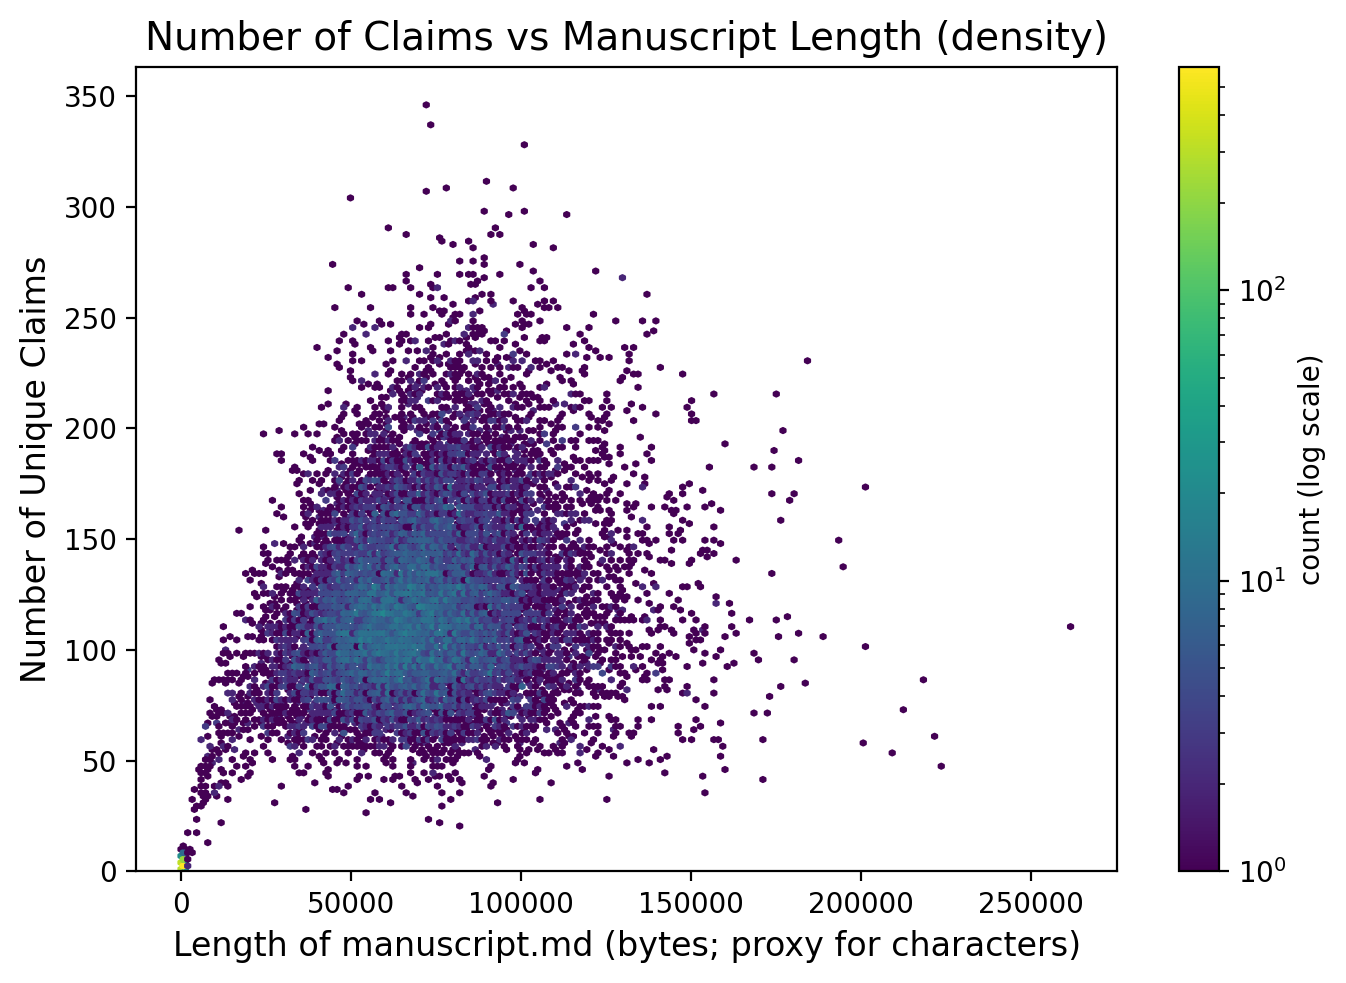

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.metrics import r2_score

# ----------------------------
# Config
# ----------------------------
md_base_dir = "/Users/laura/Documents/TBC/evals/manuscripts"

# Plot options
use_density_plot = True   # True = hexbin density (recommended). False = rasterized scatter
dot_color = "grey"
dot_size = 1              # only used for scatter
dot_alpha = 0.15          # only used for scatter

# ----------------------------
# 1) Vectorized: unique-claim counts per (manuscript_id, version)
# ----------------------------
required_cols = {"manuscript_id", "version", "claim_id"}
if not required_cols.issubset(df_claims.columns):
    raise ValueError(f"df_claims must contain columns: {sorted(required_cols)}")

claims_per_manuscript = (
    df_claims
    .groupby(["manuscript_id", "version"])["claim_id"]
    .nunique()
    .reset_index()
    .rename(columns={"claim_id": "num_claims"})
)

# ----------------------------
# 2) Fast: manuscript lengths (characters-ish) from file bytes
#    (binary read is much faster than decoding text)
# ----------------------------
records = []
missing_files = 0
read_errors = 0

for manuscript_id, version, num_claims in claims_per_manuscript.itertuples(index=False):
    md_path = os.path.join(md_base_dir, str(manuscript_id), str(version), "manuscript.md")
    if not os.path.isfile(md_path):
        missing_files += 1
        continue

    try:
        with open(md_path, "rb") as f:
            length = len(f.read())  # length in bytes; fast proxy for "characters"
    except OSError:
        read_errors += 1
        continue

    records.append((manuscript_id, version, length, int(num_claims)))

df_plot = pd.DataFrame(
    records,
    columns=["manuscript_id", "version", "manuscript_length", "num_claims"]
).sort_values("manuscript_length")

manuscript_lengths_sorted = df_plot["manuscript_length"].to_numpy()
num_claims_sorted = df_plot["num_claims"].to_numpy()

print(f"Found {len(df_plot):,} manuscripts with manuscript.md")
if missing_files:
    print(f"Missing manuscript.md for {missing_files:,} (manuscript_id, version) pairs")
if read_errors:
    print(f"Read errors for {read_errors:,} files")

# ----------------------------
# 3) R^2 (linear fit)
# ----------------------------
x = manuscript_lengths_sorted
y = num_claims_sorted

if len(x) > 1:
    coeffs = np.polyfit(x, y, 1)
    y_pred = np.poly1d(coeffs)(x)
    r2 = r2_score(y, y_pred)
    print(f"R^2 (number of claims vs manuscript length): {r2:.3f}")

# ----------------------------
# 4) Plot (fast)
# ----------------------------
plt.figure(figsize=(7, 5))

if use_density_plot:
    # Density plot scales to millions of points easily
    plt.hexbin(x, y, gridsize=200, mincnt=1, norm=LogNorm())
    plt.colorbar(label="count (log scale)")
    plt.title("Number of Claims vs Manuscript Length (density)", fontsize=14)
else:
    # If you still want scatter: rasterize + tiny markers
    plt.scatter(x, y, s=dot_size, alpha=dot_alpha, color=dot_color,
                rasterized=True, linewidths=0)
    plt.title("Number of Claims vs Manuscript Length", fontsize=14)

plt.xlabel("Length of manuscript.md (bytes; proxy for characters)", fontsize=12)
plt.ylabel("Number of Unique Claims", fontsize=12)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

# Plot claim types

/Users/laura/anaconda3/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/laura/anaconda3/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

<Figure size 800x600 with 0 Axes>

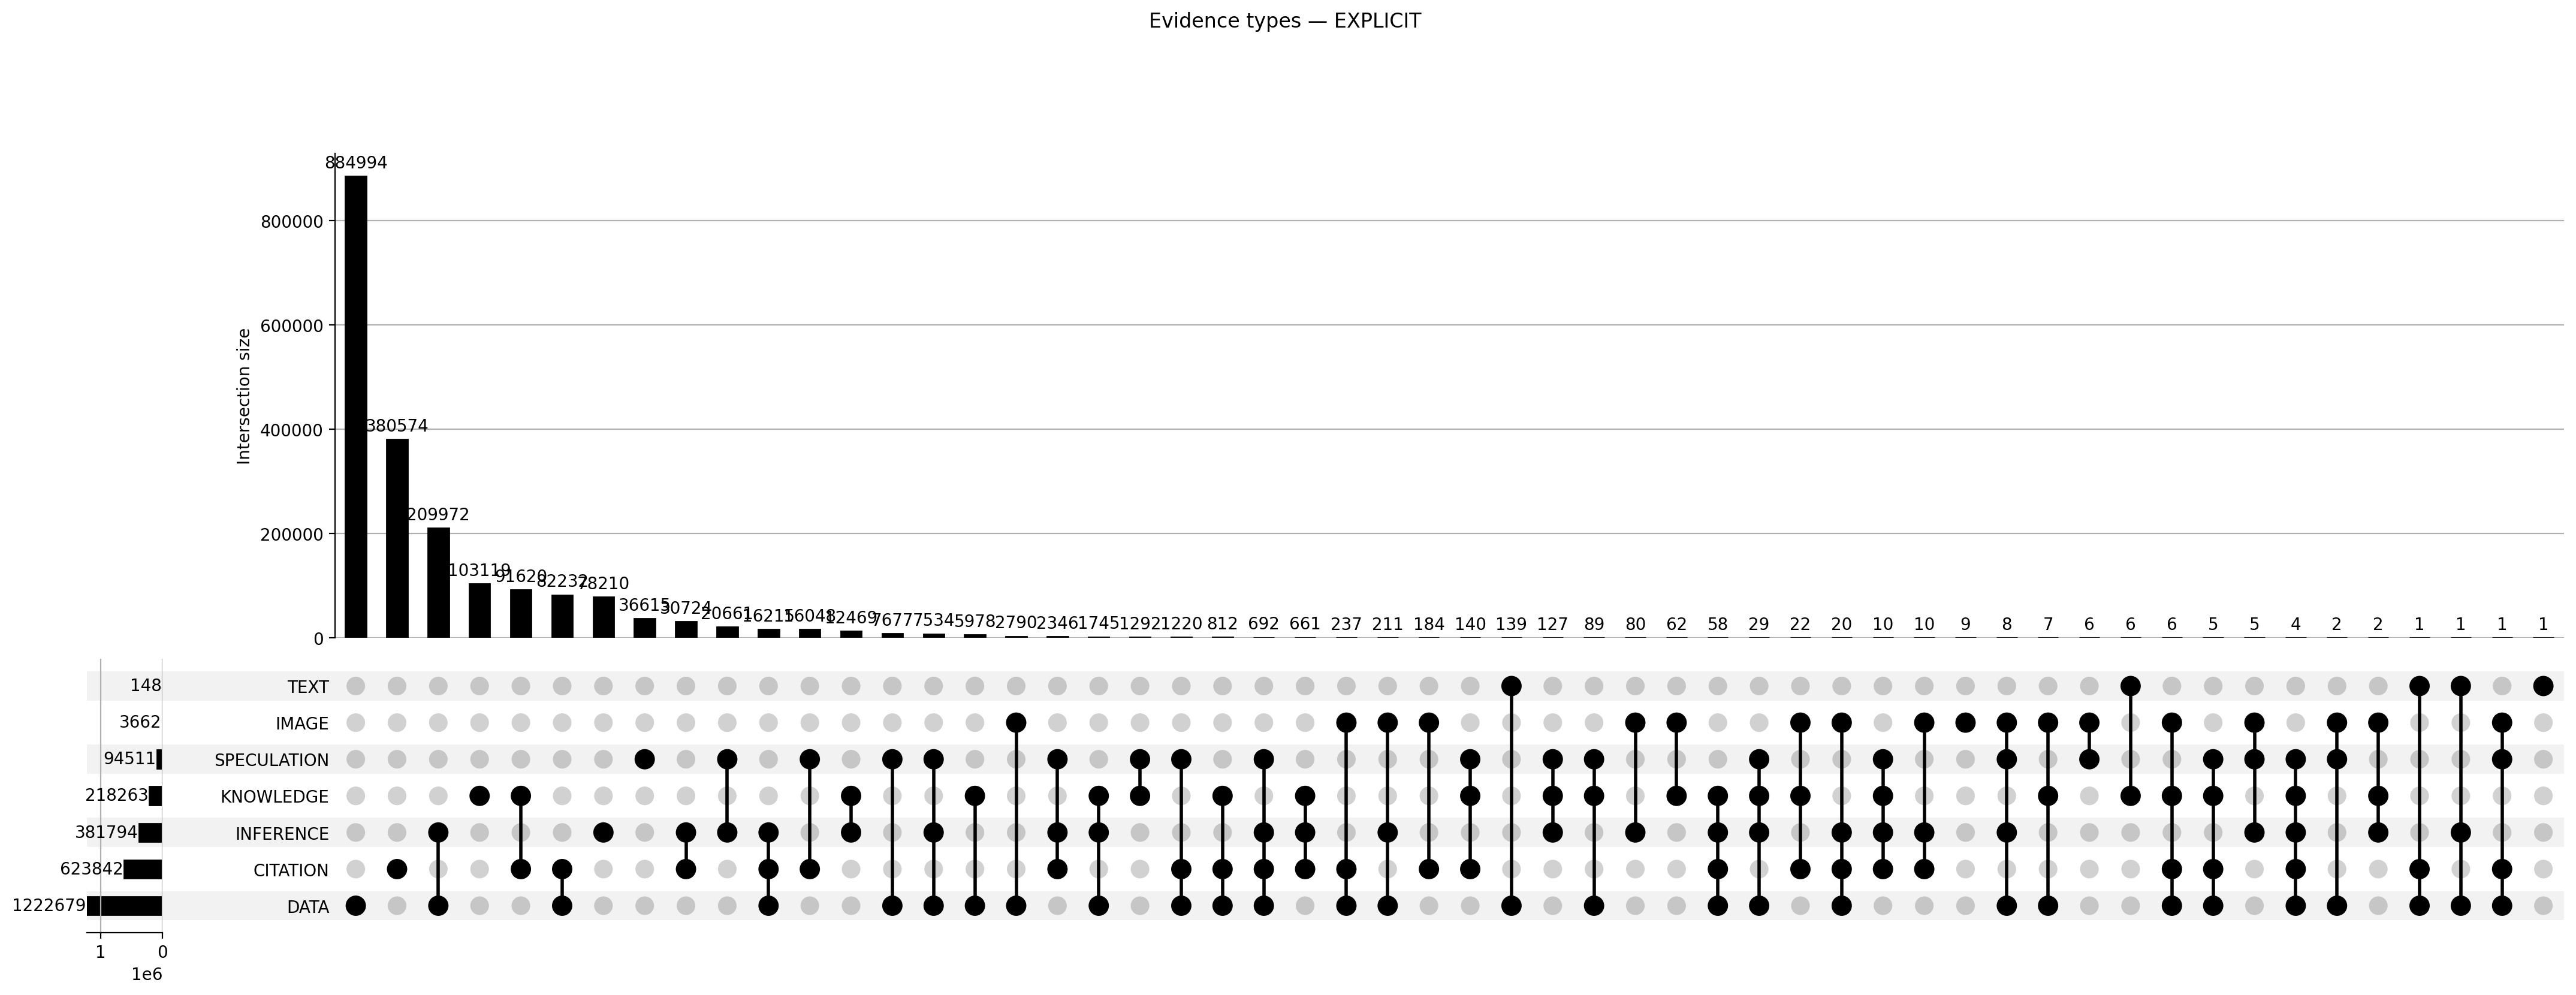

/Users/laura/anaconda3/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/laura/anaconda3/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

<Figure size 800x600 with 0 Axes>

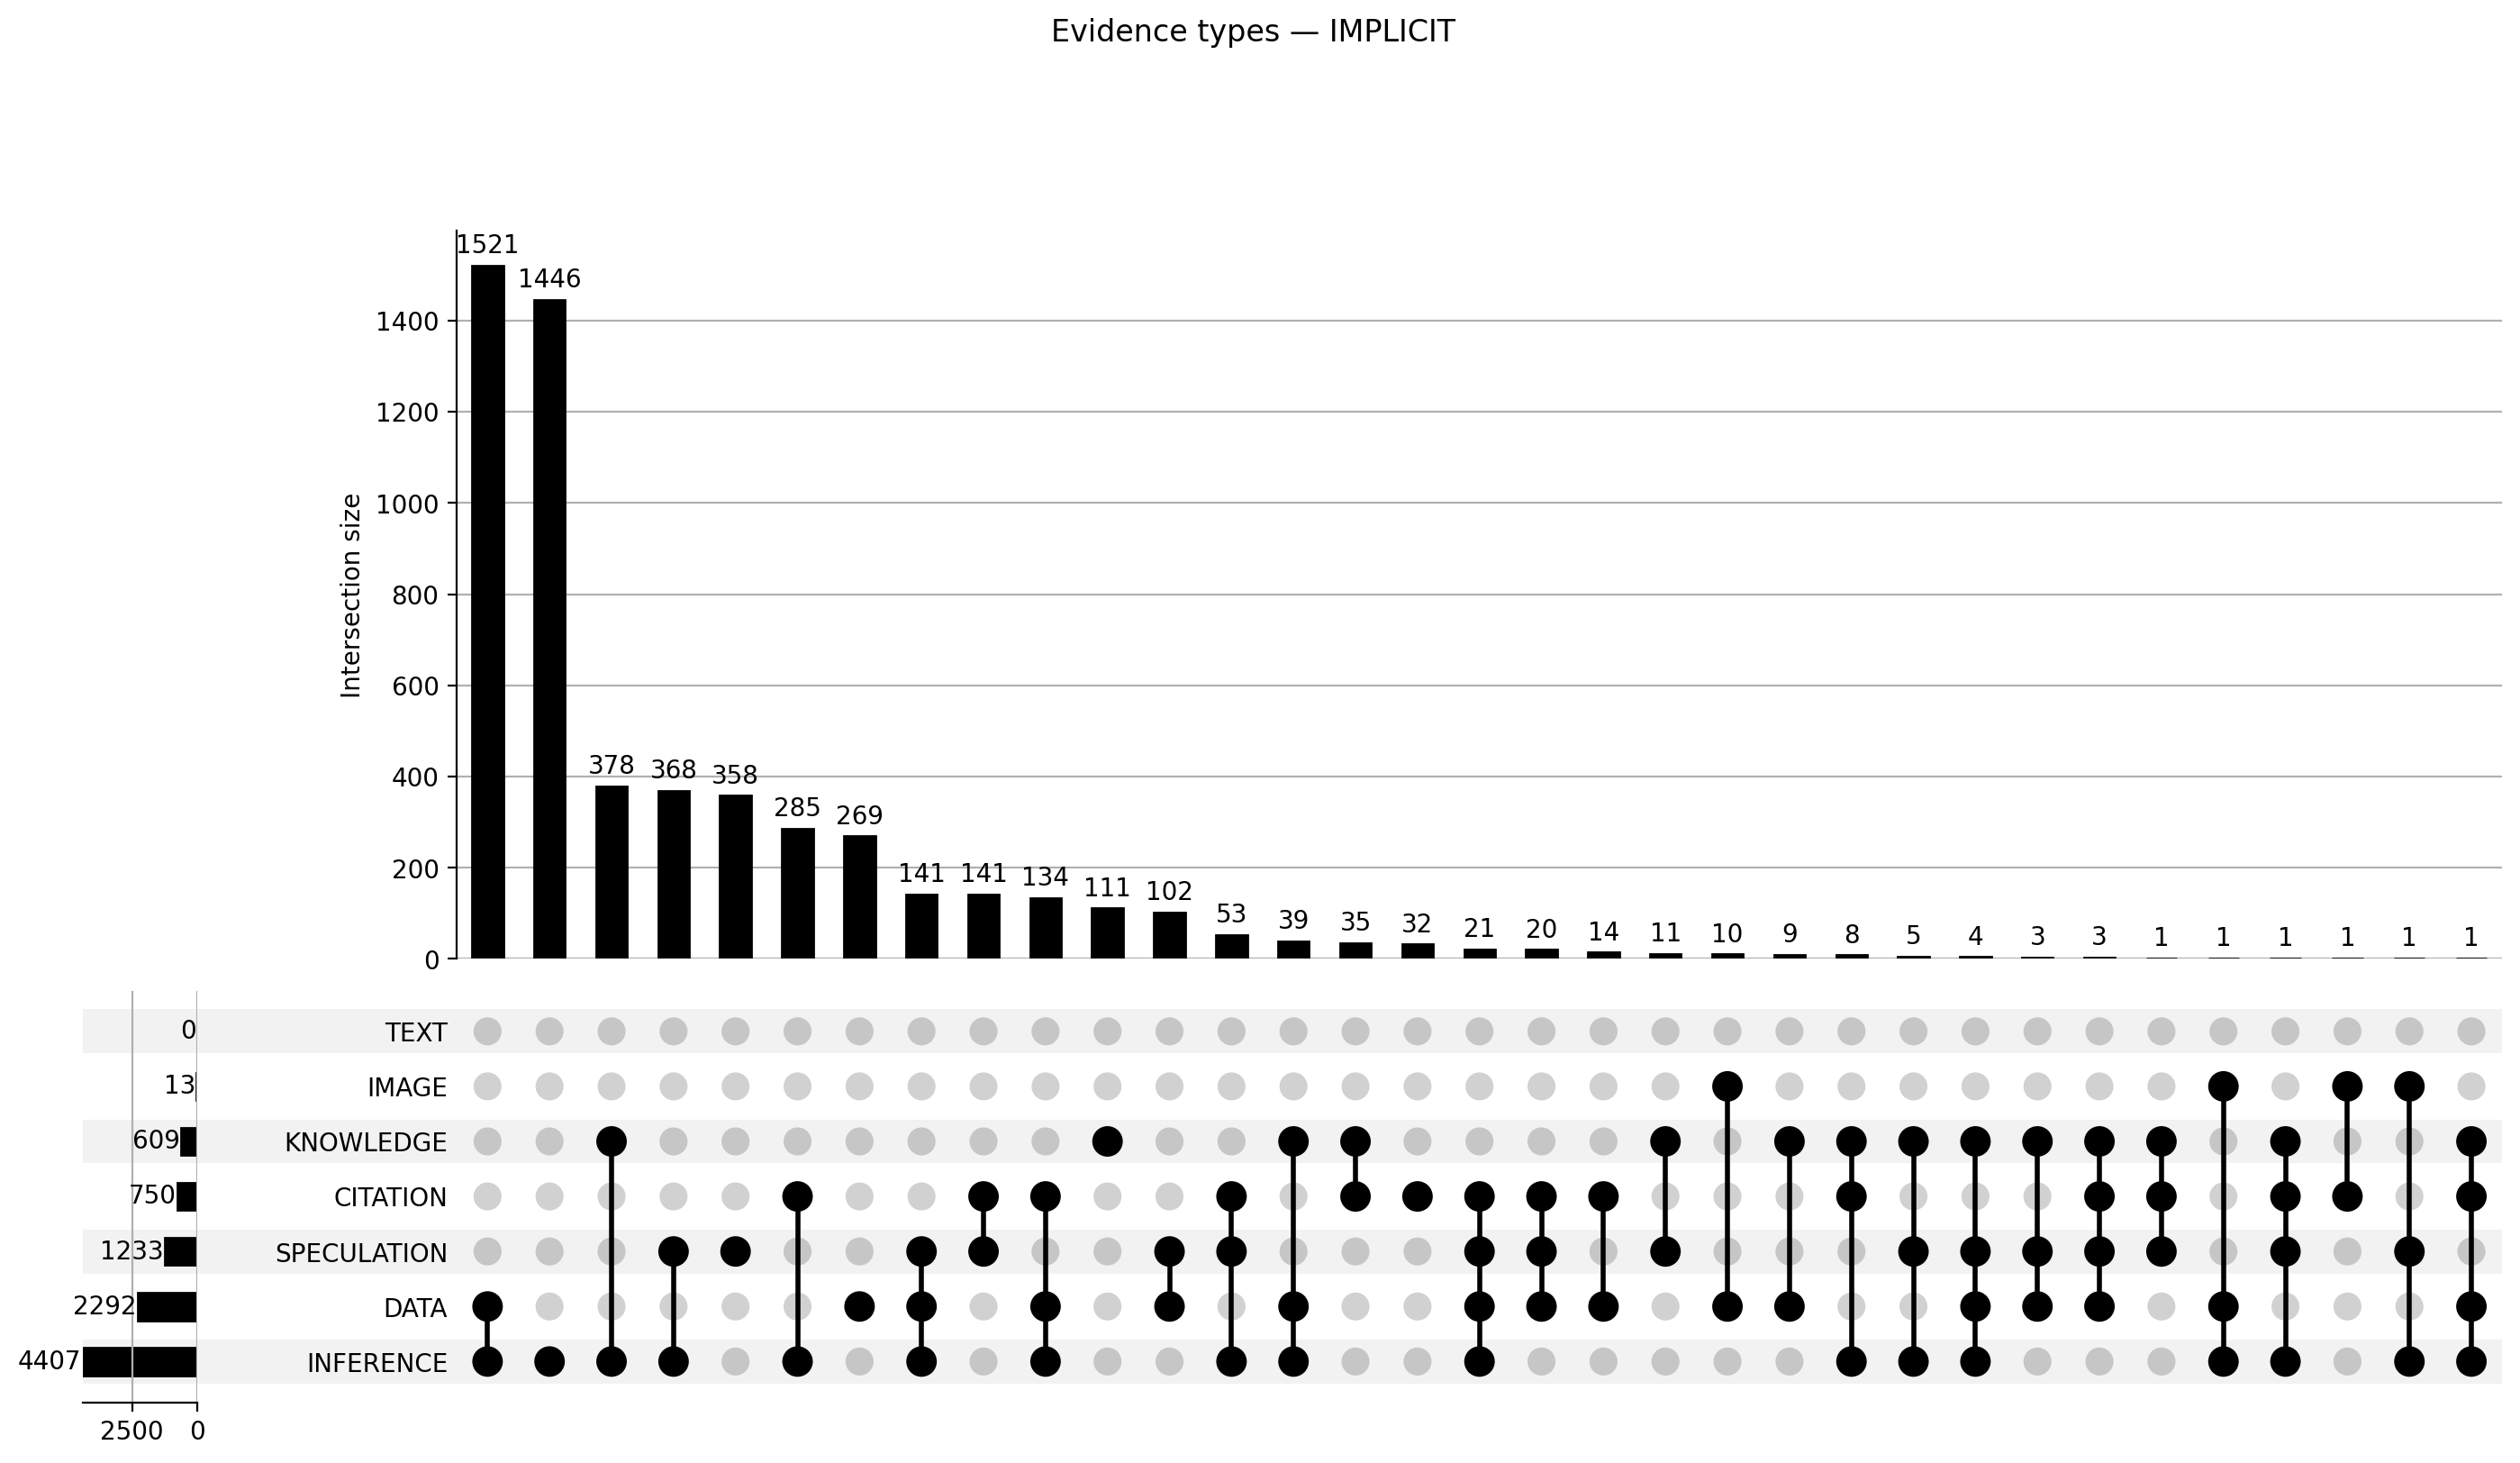

In [17]:
# pip install upsetplot

import re
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet

def parse_evidence_types(val):
    if val is None or (isinstance(val, float) and pd.isna(val)) or (isinstance(val, str) and not val.strip()):
        return []
    if isinstance(val, (list, tuple, set)):
        return sorted({str(x).strip().upper() for x in val if str(x).strip()})

    s = str(val).strip()
    s = re.sub(r"^\[|\]$", "", s)
    return sorted({t.strip().upper() for t in s.split(",") if t.strip()})

# --- prepare dataframe ---
df = df_claims.copy()
df["claim_type_norm"] = df["claim_type"].astype(str).str.strip().str.upper()
df = df[df["claim_type_norm"].isin(["EXPLICIT", "IMPLICIT"])].copy()

df["evidence_types_list"] = df["evidence_type"].apply(parse_evidence_types)

all_ev_types = sorted({ev for lst in df["evidence_types_list"] for ev in lst})

# indicator matrix
indicators = pd.DataFrame(
    {ev: df["evidence_types_list"].apply(lambda xs, ev=ev: ev in xs) for ev in all_ev_types},
    index=df.index,
)

# --- plot separately for each claim type ---
for ct in ["EXPLICIT", "IMPLICIT"]:
    ind_sub = indicators.loc[df["claim_type_norm"] == ct]

    if ind_sub.empty:
        print(f"No rows for {ct}")
        continue

    # Build the MultiIndex Series expected by upsetplot
    s = (
        ind_sub
        .astype(bool)
        .groupby(all_ev_types)
        .size()
    )
    s.index = s.index.set_names(all_ev_types)

    plt.figure(figsize=(8, 6))
    UpSet(
        s,
        show_counts=True,
        sort_by="cardinality",
        intersection_plot_elements=12,
    ).plot()

    plt.suptitle(f"Evidence types — {ct}", y=1.02)
    plt.show()

In [18]:
def prep_long(df: pd.DataFrame) -> pd.DataFrame:
    """
    Produces a long-form table with exploded evidence_type and source_type.

    Output columns include:
      - manuscript_id, claim_id, claim_type
      - evidence_cat (single category)
      - source_cat (single category)
    """
    d = df.copy()
    # Ensure these exist
    for col in ["evidence_type", "source_type", "claim_type", "manuscript_id", "claim_id"]:
        if col not in d.columns:
            raise KeyError(f"Missing expected column: {col}")

    d["evidence_list"] = d["evidence_type"].map(parse_bracket_list)
    d["source_list"]   = d["source_type"].map(parse_bracket_list)

    # explode evidence first
    long = d.explode("evidence_list", ignore_index=True)
    long = long.rename(columns={"evidence_list": "evidence_cat"})

    # then explode source types
    long = long.explode("source_list", ignore_index=True)
    long = long.rename(columns={"source_list": "source_cat"})

    # clean empties
    long["evidence_cat"] = long["evidence_cat"].fillna("").astype(str).str.strip()
    long["source_cat"]   = long["source_cat"].fillna("").astype(str).str.strip()

    long = long[(long["evidence_cat"] != "") & (long["source_cat"] != "")]
    return long

def parse_bracket_list(x):
    """
    Turns strings like "[TEXT, IMAGE]" or "[CITATION, KNOWLEDGE]" into ["TEXT","IMAGE"].
    If already list/tuple/set -> list.
    If NaN/None -> [].
    Else -> [str(x)].
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple, set)):
        return [str(v).strip() for v in x if str(v).strip()]
    s = str(x).strip()
    m = _list_re.match(s)
    if m:
        inner = m.group(1).strip()
        if not inner:
            return []
        return [t.strip() for t in inner.split(",") if t.strip()]
    return [s] if s else []

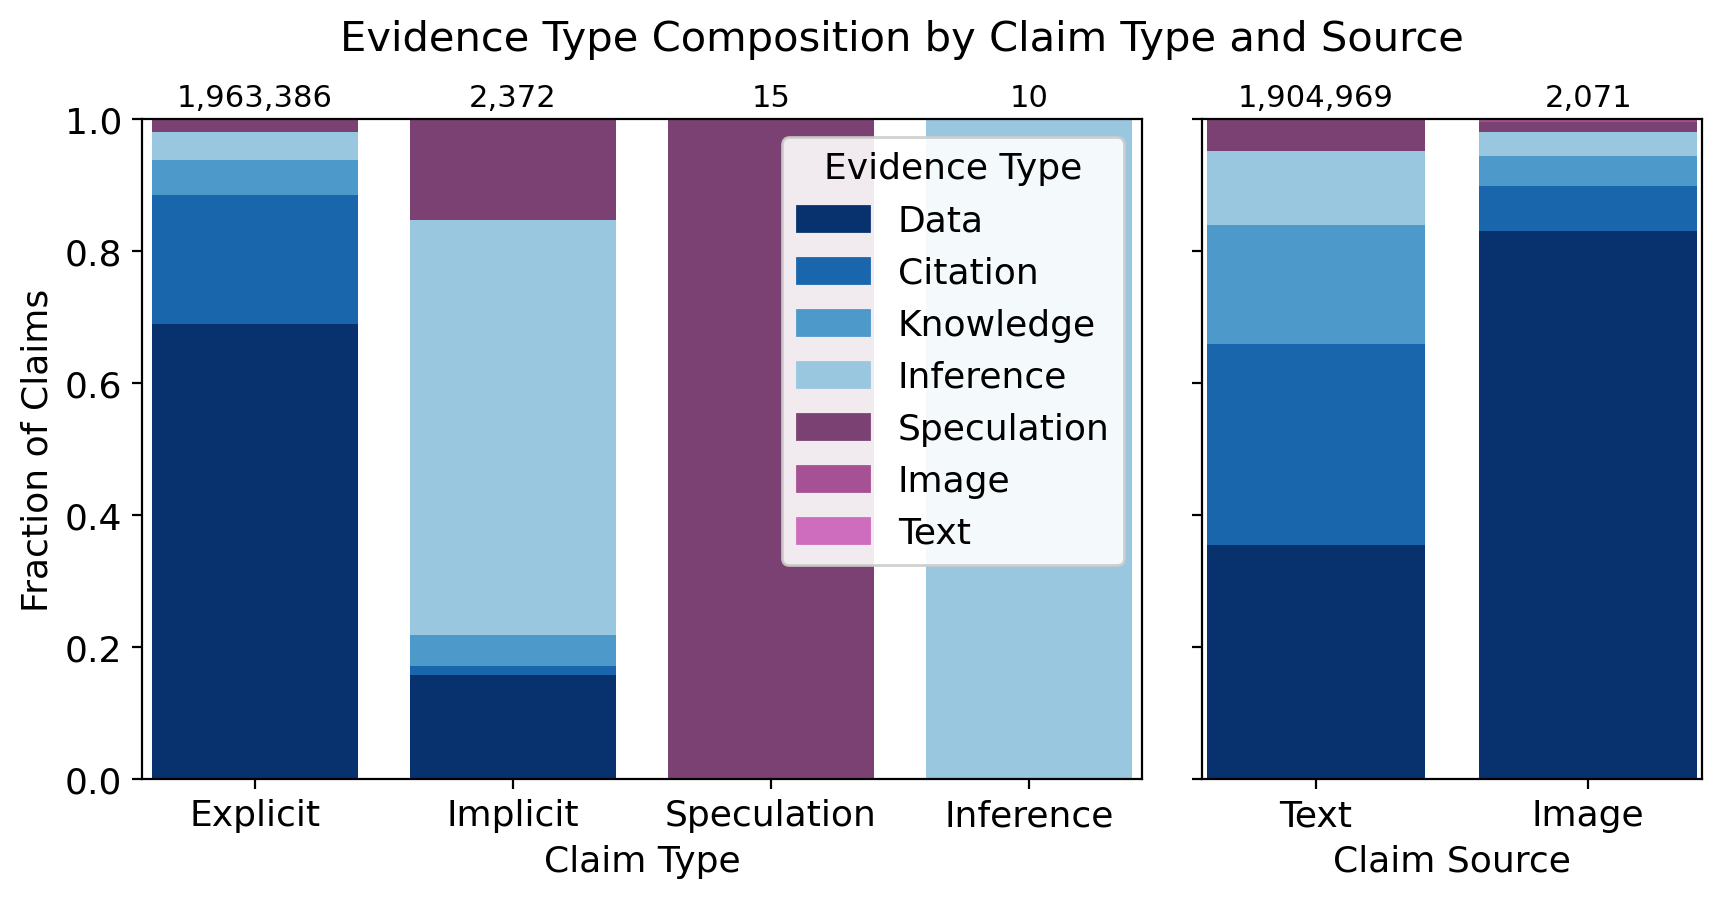

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator

def plot_evidence_by_claim_and_source_single_evidence(
    df_claims,
    top_k_evidence=10,
    normalize_within_group=True,
    bar_width=0.8,
    fontsize=13,
    max_source_ticks=10,
    figsize=(10, 5),
):
    long_all = prep_long(df_claims).copy()

    # ----------------------------
    # Helpers
    # ----------------------------
    def _count_listlike(val) -> int:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return 0
        if isinstance(val, (list, tuple, set)):
            return len(val)
        s = str(val).strip().strip("[]").strip()
        if not s:
            return 0
        return len([t for t in (x.strip() for x in s.split(",")) if t])

    def _cap(label) -> str:
        s = "" if label is None else str(label)
        return s.lower().capitalize()

    def _bucket_top_k(series: pd.Series, k: int, other="OTHER"):
        top = series.value_counts().head(k).index.tolist()
        return np.where(series.isin(top), series, other)

    def _stacked_table(df: pd.DataFrame, group_col: str, cat_col: str, cat_order: list) -> pd.DataFrame:
        return (
            df.groupby([group_col, cat_col])
              .size()
              .unstack(fill_value=0)
              .reindex(columns=cat_order, fill_value=0)
        )

    def _draw_stacked_bars(ax, df, group_col, group_order, cat_order, cat_label_map, xlabel, show_legend_labels):
        raw = _stacked_table(df, group_col, "evidence_cat_k", cat_order)
        totals = raw.sum(axis=1)

        if normalize_within_group:
            denom = raw.sum(axis=1).replace(0, np.nan)
            tab = raw.div(denom, axis=0).fillna(0.0)
            ylab = "Fraction of Claims"
            y_top_for_labels = 1.0
            ax.set_ylim(0, 1)
        else:
            tab = raw
            ylab = "Count"
            y_top_for_labels = float(raw.sum(axis=1).max()) if len(raw) else 1.0

        x = np.arange(len(group_order))
        bottoms = np.zeros(len(group_order), dtype=float)

        # palette = ["#495867", "#577399", "#BDD5EA", "#956E8C", "#DDCAD9", "lightgrey", "#FE5F55"]
        palette = [
            plt.get_cmap('Blues')(0.99),
            plt.get_cmap('Blues')(0.79),
            plt.get_cmap('Blues')(0.59),
            plt.get_cmap('Blues')(0.39),
            # "#393b79",
            # "#5254a3",
            # "#6b6ecf",
            # "#9c9ede",
            # "#637939",
            # "#8ca252",
            # "#b5cf6b",
            # "#cedb9c",
            # "#8c6d31",
            # "#bd9e39",
            # "#e7ba52",
            # "#e7cb94",
            # "#843c39",
            # "#ad494a",
            # "#d6616b",
            # "#e7969c",
            "#7b4173",
            "#a55194",
            "#ce6dbd",
            "#de9ed6",
        ]
        colors = (palette * ((len(cat_order) // len(palette)) + 1))[:len(cat_order)]
        color_map = {cat: colors[i] for i, cat in enumerate(cat_order)}

        # cmap = plt.get_cmap('tab20b')
        # colors = [cmap(i) for i in range(len(cat_order))]
        # color_map = {cat: colors[i] for i, cat in enumerate(cat_order)}

        for cat in cat_order:
            heights = np.array([tab.loc[g, cat] if g in tab.index else 0.0 for g in group_order], dtype=float)
            ax.bar(
                x,
                heights,
                width=bar_width,
                bottom=bottoms,
                color=color_map[cat],
                edgecolor="none",
                label=cat_label_map.get(cat, str(cat)) if show_legend_labels else None,
            )
            bottoms += heights

        # N labels above bars (counts even when normalized)
        for i, g in enumerate(group_order):
            n_g = int(totals.get(g, 0))
            if n_g > 0:
                ax.text(
                    x[i],
                    y_top_for_labels + 0.01 * y_top_for_labels,
                    f"{n_g:,}",
                    ha="center",
                    va="bottom",
                    fontsize=fontsize - 2,
                )

        ax.set_xticks(x)
        ax.set_xticklabels([_cap(g) for g in group_order], fontsize=fontsize, rotation=0)
        ax.set_xlabel(xlabel, fontsize=fontsize)
        ax.tick_params(axis="x", labelsize=fontsize)
        ax.tick_params(axis="y", labelsize=fontsize)
        ax.margins(x=0.01)

        return ylab, color_map

    # ----------------------------
    # Left: single evidence
    # ----------------------------
    long_left = long_all.copy()
    if "evidence_types_list" in long_left.columns:
        ev_count = long_left["evidence_types_list"].apply(_count_listlike)
    else:
        if "evidence_type" not in long_left.columns:
            raise ValueError("Need 'evidence_types_list' or 'evidence_type' to filter to single-evidence claims.")
        ev_count = long_left["evidence_type"].apply(_count_listlike)

    long_left = long_left[ev_count == 1].copy()
    if long_left.empty:
        raise ValueError("No rows left after filtering to claims with exactly one evidence type.")

    long_left["evidence_cat_k"] = _bucket_top_k(long_left["evidence_cat"], top_k_evidence, other="OTHER")
    claim_order = long_left["claim_type"].value_counts().index.tolist()
    evidence_order_left = long_left["evidence_cat_k"].value_counts().index.tolist()
    evidence_label_left = {ev: _cap(ev) for ev in evidence_order_left}

    # ----------------------------
    # Right: single source
    # ----------------------------
    long_right = long_all.copy()
    if "source_type" in long_right.columns:
        st_count = long_right["source_type"].apply(_count_listlike)
        long_right = long_right[st_count == 1].copy()

    if long_right.empty:
        raise ValueError("No rows left after filtering to claims with exactly one source type.")
    if "source_cat" not in long_right.columns:
        raise ValueError("Expected 'source_cat' from prep_long(df_claims).")

    long_right["evidence_cat_k"] = _bucket_top_k(long_right["evidence_cat"], top_k_evidence, other="OTHER")
    evidence_order_right = long_right["evidence_cat_k"].value_counts().index.tolist()
    evidence_label_right = {ev: _cap(ev) for ev in evidence_order_right}

    source_order = long_right["source_cat"].value_counts().index.tolist()
    if len(source_order) > max_source_ticks:
        top_sources = source_order[:max_source_ticks]
        long_right["source_cat_k"] = np.where(long_right["source_cat"].isin(top_sources), long_right["source_cat"], "OTHER")
        source_order_k = [*top_sources, "OTHER"]
    else:
        long_right["source_cat_k"] = long_right["source_cat"]
        source_order_k = source_order

    # ----------------------------
    # Plot
    # ----------------------------
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, width_ratios=[2, 1], figure=fig)
    ax_claim = fig.add_subplot(gs[0, 0])
    ax_source = fig.add_subplot(gs[0, 1], sharey=ax_claim)

    ylab, color_map_left = _draw_stacked_bars(
        ax_claim,
        long_left,
        group_col="claim_type",
        group_order=claim_order,
        cat_order=evidence_order_left,
        cat_label_map=evidence_label_left,
        xlabel="Claim Type",
        show_legend_labels=True,
    )
    ax_claim.set_ylabel(ylab, fontsize=fontsize)
    ax_claim.yaxis.set_major_locator(MaxNLocator(5))

    _ylab2, _ = _draw_stacked_bars(
        ax_source,
        long_right,
        group_col="source_cat_k",
        group_order=source_order_k,
        cat_order=evidence_order_right,
        cat_label_map=evidence_label_right,
        xlabel="Claim Source",
        show_legend_labels=False,
    )

    # --- Desired behavior ---
    # Left: show y ticks + labels
    ax_claim.tick_params(axis="y", which="both", left=True, labelleft=True)

    # Right: keep y axis + tick marks, but hide tick labels only
    ax_source.tick_params(axis="y", which="both", left=True, labelleft=False)

    # Keep the left spine visible on the right subplot (do NOT hide it)
    ax_source.spines["left"].set_visible(True)

    # Legend (left only)
    handles = [mpatches.Patch(color=color_map_left[ev], label=evidence_label_left[ev]) for ev in evidence_order_left]
    leg = ax_claim.legend(
        handles=handles,
        title="Evidence Type",
        loc="upper right",
        fontsize=fontsize,
        title_fontsize=fontsize,
        frameon=True,
    )
    if leg is not None:
        leg.get_frame().set_alpha(0.9)

    # Spacing so left y tick labels have room
    fig.subplots_adjust(left=0.12, bottom=0.22, wspace=0.08)

    fig.suptitle("Evidence Type Composition by Claim Type and Source", fontsize=fontsize + 2, y=0.98)

    return fig, (ax_claim, ax_source)

fig, axes = plot_evidence_by_claim_and_source_single_evidence(
    df_claims,
    top_k_evidence=10,
    normalize_within_group=True,
)

fig.savefig("figures/3_evidence_composition_by_claim_and_source.png", dpi=300, bbox_inches="tight")

plt.show()


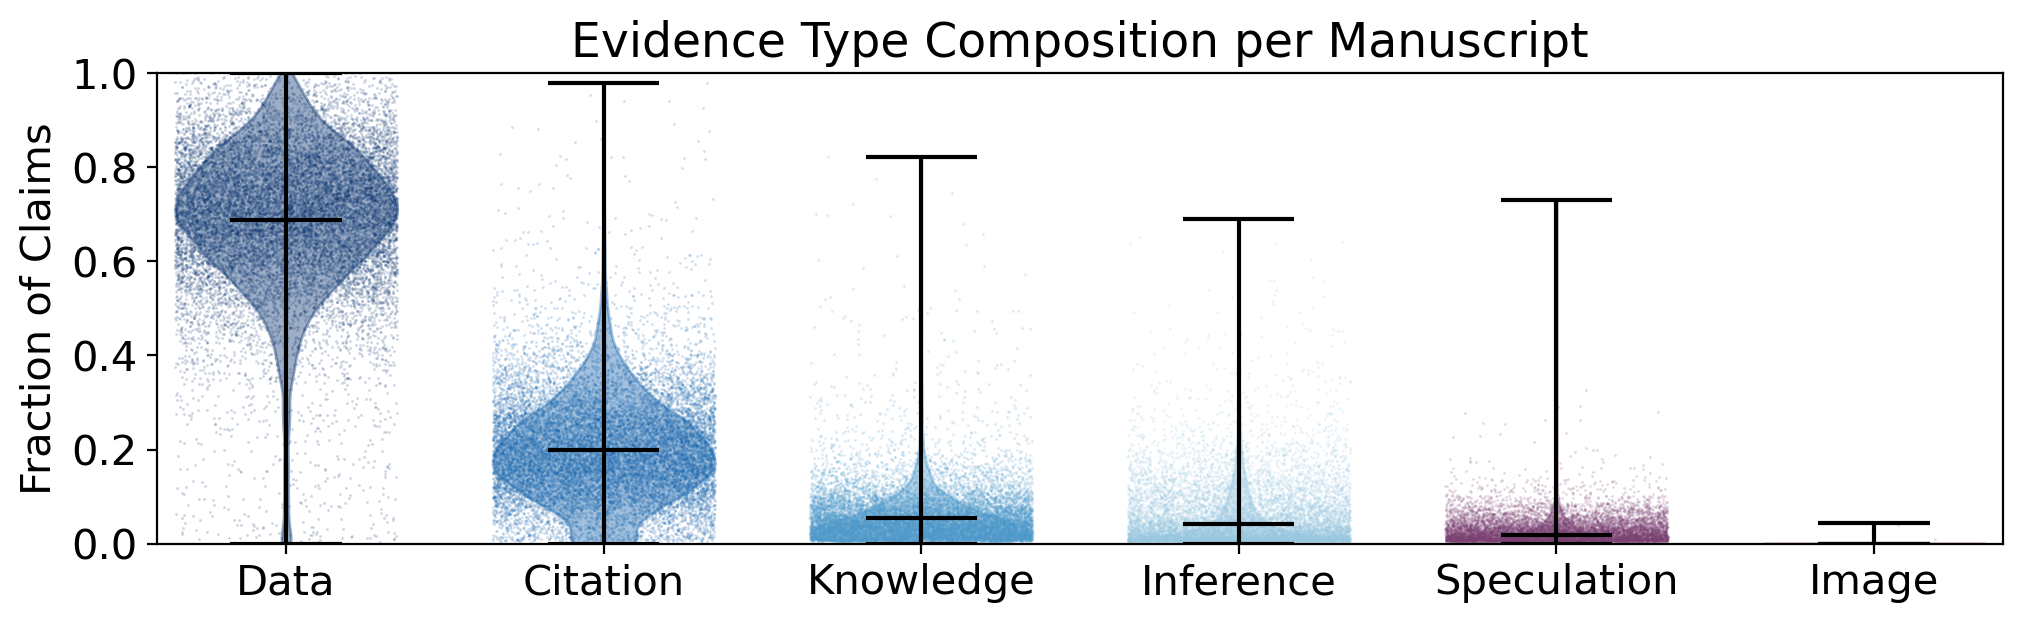

In [ ]:
# Set fontsize for ticklabels, axis labels, and titles
fontsize = 15

def _topk_categories(series: pd.Series, k: int = 8):
    vc = series.value_counts()
    keep = list(vc.head(k).index)
    return keep

def plot_evidence_fractions_violin(df_claims: pd.DataFrame, top_k: int = 8, min_claims: int = 50, fontsize: int = fontsize):
    """
    Violin plot: distributions of evidence category fractions across manuscripts,
    including only claims with exactly one evidence type.
    Each violin shows the distribution (across manuscripts) of the proportion of claims using that evidence type.
    Overlays a scatter plot of individual data points.
    """

    long = prep_long(df_claims).copy()

    # --- Filter for claims with exactly one evidence type, as in the reference code ---
    def _count_listlike(val) -> int:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return 0
        if isinstance(val, (list, tuple, set)):
            return len(val)
        s = str(val).strip().strip("[]").strip()
        if not s:
            return 0
        return len([t for t in (x.strip() for x in s.split(",")) if t])

    if "evidence_types_list" in long.columns:
        ev_count = long["evidence_types_list"].apply(_count_listlike)
    else:
        if "evidence_type" not in long.columns:
            raise ValueError("Need 'evidence_types_list' or 'evidence_type' to filter to single-evidence claims.")
        ev_count = long["evidence_type"].apply(_count_listlike)

    long = long[ev_count == 1].copy()
    if long.empty:
        raise ValueError("No rows left after filtering to claims with exactly one evidence type.")

    # topk evidence types, rest as "OTHER"
    keep = _topk_categories(long["evidence_cat"], k=top_k)
    long["evidence_cat_k"] = np.where(long["evidence_cat"].isin(keep), long["evidence_cat"], "OTHER")

    manus_sizes = long.groupby("manuscript_id").size()
    good_manus = manus_sizes[manus_sizes >= min_claims].index
    long = long[long["manuscript_id"].isin(good_manus)]

    evidence_order = (
        pd.Series(long["evidence_cat_k"])
        .value_counts()
        .index.tolist()
    )

    # Manuscript × evidence tabulation (proportions)
    tab = (
        long.groupby(["manuscript_id", "evidence_cat_k"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=evidence_order, fill_value=0)
    )
    props = tab.div(tab.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    # Prepare data for violinplot: list of arrays, one per evidence type, each array is the props per manuscript
    data = [props[e].values for e in evidence_order]

    fig, ax = plt.subplots(1, 1, figsize=(10,3), constrained_layout=True)
    vp = ax.violinplot(data, showmeans=True, widths=0.7)

    # --- Use a color palette for violin colors, matching the order and looping as needed ---
    palette = [
        plt.get_cmap('Blues')(0.99),
        plt.get_cmap('Blues')(0.79),
        plt.get_cmap('Blues')(0.59),
        plt.get_cmap('Blues')(0.39),
        "#7b4173",
        "#a55194",
        "#ce6dbd",
        "#de9ed6",
    ]
    # Extend palette if fewer colors than violins
    from itertools import cycle, islice
    violin_colors = list(islice(cycle(palette), len(evidence_order)))

    # Set each violin body color
    for pc, violin_color in zip(vp['bodies'], violin_colors):
        pc.set_facecolor(violin_color)
        pc.set_edgecolor(violin_color)
        pc.set_alpha(0.4)

    # Always keep mean/median/statistics lines in violin black
    for partname in ['cmeans', 'cmins', 'cmaxes', 'cmedians', 'cbars']:
        part = vp.get(partname)
        if part is not None:
            # May be a LineCollection or list of lines (for means, bars, etc)
            if hasattr(part, '__len__') and len(part) == len(evidence_order):
                for line in part:
                    if hasattr(line, "set_color"):
                        line.set_color("black")
                    elif hasattr(line, "set_edgecolor"):
                        line.set_edgecolor("black")
                    line.set_linewidth(1.5)
                    if hasattr(line, "set_alpha"):
                        line.set_alpha(1)
            else:
                # fallback: just use black
                if hasattr(part, "set_color"):
                    part.set_color("black")
                elif hasattr(part, "set_edgecolor"):
                    part.set_edgecolor("black")
                part.set_linewidth(1.5)
                if hasattr(part, "set_alpha"):
                    part.set_alpha(1)

    ax.set_xticks(np.arange(1, len(evidence_order)+1))
    xtick_labels = [e.capitalize() for e in evidence_order]
    ax.set_xticklabels(xtick_labels, rotation=0, fontsize=fontsize)
    # ax.set_xlabel("Evidence Type", fontsize=fontsize)
    ax.set_ylabel("Fraction of Claims", fontsize=fontsize)
    ax.set_title("Evidence Type Composition per Manuscript", fontsize=fontsize+2)
    ax.margins(x=0.01)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='y', labelsize=fontsize)

    # Overlay scatter plot (strip plot) with less wide horizontal jitter/error
    for i, (arr, violin_color) in enumerate(zip(data, violin_colors)):
        jitter = (np.random.rand(len(arr)) - 0.5) * 0.7
        x_arr = np.full_like(arr, i+1, dtype=float) + jitter
        # Overlay scatter dots (alpha and size as desired)
        ax.scatter(x_arr, arr, alpha=0.2, color=violin_color, s=1, linewidths=0)

    return fig, ax

# 4) Evidence category fraction violin plot across manuscripts
fig, ax = plot_evidence_fractions_violin(df_claims, top_k=8, min_claims=50, fontsize=fontsize)
fig.savefig("figures/3_evidence_fractions_violin.png", dpi=300, bbox_inches="tight")

plt.show()